In [1234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1235]:
data_amzn = pd.read_csv("./dataset/portfolio_data.csv")

In [1236]:
data_amzn = data_amzn.drop(["DPZ", "BTC", "NFLX"], axis=1)

In [1237]:
data_amzn.head()

,Date,AMZN
0,5/1/2013,248.229996
1,5/2/2013,252.550003
2,5/3/2013,258.049988
3,5/6/2013,255.720001
4,5/7/2013,257.730011


In [1238]:
data_amzn.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   AMZN    1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [1239]:
data_amzn.isnull().sum()

Date    0
AMZN    0
dtype: int64

In [1240]:
data_amzn.shape

(1520, 2)

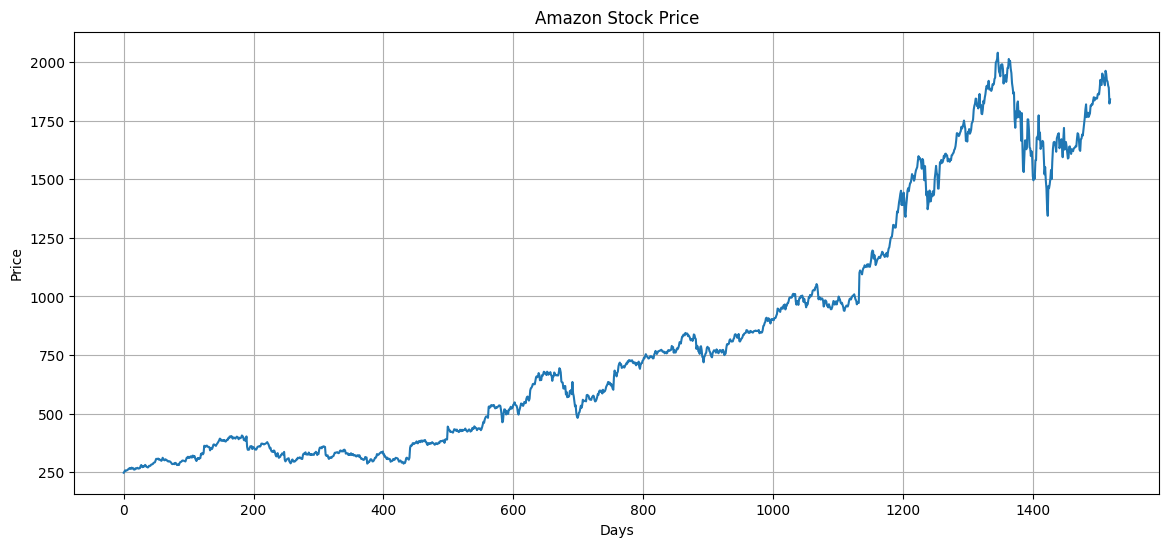

In [1241]:
plt.figure(figsize=(14, 6))
plt.plot(data_amzn['AMZN'])
plt.title("Amazon Stock Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid()
plt.show()

In [1242]:
price = data_amzn["AMZN"].values
print(type(price))

<class 'numpy.ndarray'>


In [1243]:
# print(price[:30])
# print(price[50])

##### input: N days that we already know the values/ output: M days that we want to predict

In [1244]:
price = data_amzn["AMZN"].values
X = []
y = []
day = 30
for index in range(len(price) - day):
    X.append(price[index: index + day])
    y.append(price[index + day])
    
X = np.array(X)
y= np.array(y)

In [1245]:
print(X.shape)
print(y.shape)

(1490, 30)
(1490,)


In [1246]:
# print(X[0])
# print(y[0])

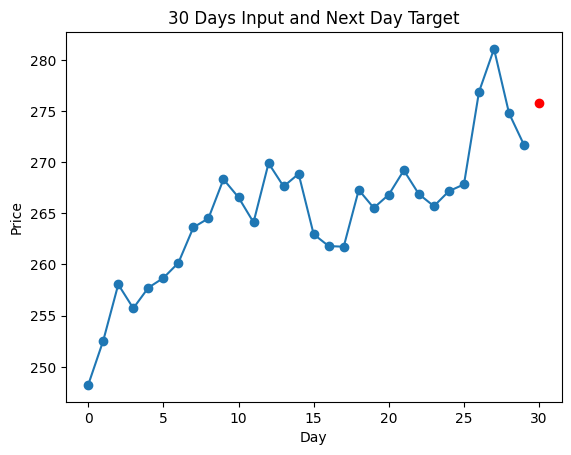

In [1247]:
plt.plot(X[0], marker= 'o')
plt.plot(30, y[0], 'ro')
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("30 Days Input and Next Day Target")
plt.show()

### Train & Test split

In [1248]:
train_size = int(len(X)* 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [1249]:
print(f'X_train shape: {X_train.shape} - X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

X_train shape: (1192, 30) - X_test shape: (298, 30)
y_train shape: (1192,) - y_test shape: (298,)


### pre-processing

In [1250]:
from sklearn.preprocessing import MinMaxScaler

model = MinMaxScaler()
X_train = model.fit_transform(X_train)
X_test = model.transform(X_test)

### Random Forest

In [1251]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500,max_depth=10,max_features="sqrt",min_samples_split=10, min_samples_leaf=5)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [1252]:
print("Train:", rf.score(X_train, y_train))
print("Test :", rf.score(X_test, y_test))

Train: 0.9990511072592997
Test : -1.692797940937942


In [1253]:
print(f"Test:", y_test[:5])
print(f"RF predicted:", rf_pred[:5])

Test: [1551.859985 1578.890015 1598.390015 1588.180054 1591.      ]
RF predicted: [1506.14267804 1504.15897017 1505.52010931 1507.11953879 1507.60787591]


In [1254]:
last_30_days = price[-30:]
print(f"Last 30 Days:", last_30_days)

last_30_days = model.transform([last_30_days])
pred = rf.predict(last_30_days)
print(f"Next day Prediction(RF):", pred)

Last 30 Days: [1813.97998  1820.699951 1818.859985 1837.280029 1849.859985 1835.839966
 1847.329956 1844.069946 1843.060059 1844.869995 1863.040039 1864.819946
 1861.689941 1887.310059 1923.77002  1901.75     1902.25     1950.630005
 1938.430054 1926.52002  1911.52002  1900.819946 1962.459961 1950.550049
 1921.       1917.77002  1899.869995 1889.97998  1822.680054 1840.119995]
Next day Prediction(RF): [1508.06618339]


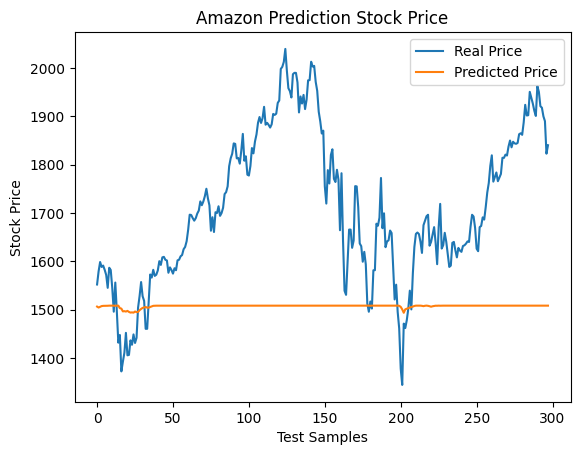

In [1255]:
plt.plot(y_test, label="Real Price")
plt.plot(rf_pred, label="Predicted Price")
plt.title("Amazon Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### SVM Regression

In [1256]:
from sklearn.svm import SVR

svm = SVR(C=100, kernel="linear") #epsilon=1, gamma="scale"
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [1257]:
print("Train:", svm.score(X_train, y_train))
print("Test:", svm.score(X_test, y_test))

Train: 0.9981746871509141
Test: 0.9305173173198638


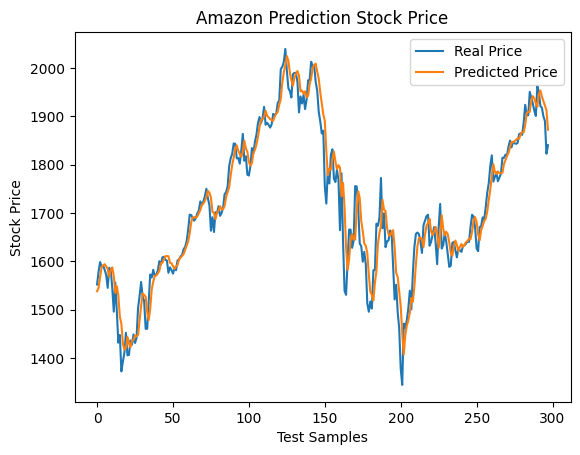

In [1258]:
plt.plot(y_test, label="Real Price")
plt.plot(svm_pred, label="Predicted Price")
plt.title("Amazon Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

#### input last 30 days and output next daye 

In [1259]:
last_30_days = price[-30:]
print(f"Last 30 Days:", last_30_days)

last_30_days = model.transform([last_30_days])

pred = svm.predict(last_30_days)

print(f"Next day Prediction:", pred)

Last 30 Days: [1813.97998  1820.699951 1818.859985 1837.280029 1849.859985 1835.839966
 1847.329956 1844.069946 1843.060059 1844.869995 1863.040039 1864.819946
 1861.689941 1887.310059 1923.77002  1901.75     1902.25     1950.630005
 1938.430054 1926.52002  1911.52002  1900.819946 1962.459961 1950.550049
 1921.       1917.77002  1899.869995 1889.97998  1822.680054 1840.119995]
Next day Prediction: [1861.01054341]


In [1260]:
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

y_train shape: (1192,) - y_test shape: (298,)


In [1261]:
prcentage = 30/295*100
print(prcentage)

10.16949152542373
